In [1]:
import os
import torch
os.environ["TORCH_VERSION"] = torch.__version__

!uv pip install torch-scatter torch-cluster -f https://pytorch-geometric.com/whl/torch-$TORCH_VERSION.html
!uv pip install torchdrug

Using Python 3.12.13 environment at: /usr
Resolved 4 packages in 1.01s
Prepared 2 packages in 547ms
Installed 2 packages in 4ms
 + torch-cluster==1.6.3+pt210cu128
 + torch-scatter==2.1.2+pt210cu128
Using Python 3.12.13 environment at: /usr
Resolved 43 packages in 890ms
Prepared 1 package in 35ms
Installed 1 package in 4ms
 + torchdrug==0.1.0


Here, we use GPU-acceralated UMAP to boost calculation of UMAP.

In [2]:
!uv pip uninstall rdkit
!uv pip install rdkit
# !pip install rdkit=="2022.09.3"

Using Python 3.12.13 environment at: /usr
Using Python 3.12.13 environment at: /usr
Resolved 3 packages in 167ms
Prepared 1 package in 749ms
Installed 1 package in 23ms
 + rdkit==2026.3.1


In [3]:
!uv pip install \
    --extra-index-url=https://pypi.nvidia.com \
    "cudf-cu12==26.2.*" "dask-cudf-cu12==26.2.*" "cuml-cu12==26.2.*" \
    "cugraph-cu12==26.2.*" "nx-cugraph-cu12==26.2.*" "cuxfilter-cu12==26.2.*" \
    "cucim-cu12==26.2.*" "pylibraft-cu12==26.2.*" "raft-dask-cu12==26.2.*" \
    "cuvs-cu12==26.2.*" "nx-cugraph-cu12==26.2.*"

Using Python 3.12.13 environment at: /usr
Resolved 178 packages in 1.39s
Prepared 11 packages in 2.37s
Uninstalled 5 packages in 300ms
Installed 11 packages in 163ms
 - bokeh==3.8.2
 + bokeh==3.6.3
 + cugraph-cu12==26.2.0
 + cuxfilter-cu12==26.2.0
 + datashader==0.19.0
 - holoviews==1.22.1
 + holoviews==1.20.2
 + jupyter-server-proxy==4.5.0
 - nvidia-cuda-nvcc-cu12==12.5.82
 + nvidia-cuda-nvcc-cu12==12.8.93
 - panel==1.8.10
 + panel==1.7.5
 + pyct==0.6.0
 - shapely==2.1.2
 + shapely==2.0.7
 + simpervisor==1.0.0


In [4]:
import cudf as pd
data_train = pd.read_csv("train_for_publication.csv")
data_train =  data_train[["SMILES", "refractive_index"]].reset_index(drop=True)
data_test = pd.read_csv("test_for_publication.csv")
data_test = data_test.rename(columns={"Experimental n": "refractive_index"})
data_test

data = pd.concat([data_train.reset_index(drop=True), data_test.reset_index(drop=True)], axis=0).reset_index(drop=True)
data

,SMILES,refractive_index,Unnamed: 0,title,Predicted density,reference
0,[*]C(C(O[*])=O)C,1.4700,<NA>,<NA>,<NA>,<NA>
1,[*]C(C)(C)C[*],1.5075,<NA>,<NA>,<NA>,<NA>
2,[*]C(c1ccc(C(OCCO[*])=O)cc1)=O,1.5700,<NA>,<NA>,<NA>,<NA>
3,[*]C/C=C(C[*])\C,1.5150,<NA>,<NA>,<NA>,<NA>
4,[*]c1ccc(S(=O)(c2ccc(Oc3ccc(c4ccc(O[*])cc4)cc3...,1.6700,<NA>,<NA>,<NA>,<NA>
5,[*]c1ccc(S(=O)(c2ccc(Oc3ccc(S(=O)(c4ccc(O[*])c...,1.5500,<NA>,<NA>,<NA>,<NA>
6,[*]CC([*])c1ccccc1,1.5250,<NA>,<NA>,<NA>,<NA>
7,[*]CC(C=C)[*],1.5400,<NA>,<NA>,<NA>,<NA>
8,[*]CO[*],1.4950,<NA>,<NA>,<NA>,<NA>
9,[*]Oc1ccc(Oc2ccc(C(c3ccc([*])cc3)=O)cc2)cc1,1.6700,<NA>,<NA>,<NA>,<NA>


In [5]:
import rdkit
rdkit.__version__

'2026.03.1'

assisted with ChatGPT

In [6]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs

# 1. preparation of dataframe
df = data.copy().to_pandas()

# 2. preparation of generator
morgan_gen = AllChem.GetMorganGenerator(radius=2, fpSize=2048)

# 3. Fingerprinting
def smiles_to_fp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
        arr = np.zeros((0,), dtype=np.int8)
        DataStructs.ConvertToNumpyArray(fp, arr)
        return arr
    else:
        return None

# 4. creating new column
df['fp'] = df['SMILES'].apply(smiles_to_fp)

# error cleaning
df = df.dropna(subset=['fp']).reset_index(drop=True)

# 5. stacking in numpy
X = np.stack(df['fp'].values)

print(f"df.shape: {df.shape}")
print(f"X.shape: {X.shape}")

df.shape: (51, 7)
X.shape: (51, 2048)


[14:13:51] DEPRECATION WARNING: please use MorganGenerator
[14:13:51] DEPRECATION WARNING: please use MorganGenerator
[14:13:51] DEPRECATION WARNING: please use MorganGenerator
[14:13:51] DEPRECATION WARNING: please use MorganGenerator
[14:13:51] DEPRECATION WARNING: please use MorganGenerator
[14:13:51] DEPRECATION WARNING: please use MorganGenerator
[14:13:51] DEPRECATION WARNING: please use MorganGenerator
[14:13:51] DEPRECATION WARNING: please use MorganGenerator
[14:13:51] DEPRECATION WARNING: please use MorganGenerator
[14:13:51] DEPRECATION WARNING: please use MorganGenerator
[14:13:51] DEPRECATION WARNING: please use MorganGenerator
[14:13:51] DEPRECATION WARNING: please use MorganGenerator
[14:13:51] DEPRECATION WARNING: please use MorganGenerator
[14:13:51] DEPRECATION WARNING: please use MorganGenerator
[14:13:51] DEPRECATION WARNING: please use MorganGenerator
[14:13:51] DEPRECATION WARNING: please use MorganGenerator
[14:13:51] DEPRECATION WARNING: please use MorganGenerat

In [7]:
df

,SMILES,refractive_index,Unnamed: 0,title,Predicted density,reference,fp
0,[*]C(C(O[*])=O)C,1.4700,NaN,None,NaN,None,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,[*]C(C)(C)C[*],1.5075,NaN,None,NaN,None,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,[*]C(c1ccc(C(OCCO[*])=O)cc1)=O,1.5700,NaN,None,NaN,None,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ..."
3,[*]C/C=C(C[*])\C,1.5150,NaN,None,NaN,None,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,[*]c1ccc(S(=O)(c2ccc(Oc3ccc(c4ccc(O[*])cc4)cc3...,1.6700,NaN,None,NaN,None,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
5,[*]c1ccc(S(=O)(c2ccc(Oc3ccc(S(=O)(c4ccc(O[*])c...,1.5500,NaN,None,NaN,None,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
6,[*]CC([*])c1ccccc1,1.5250,NaN,None,NaN,None,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
7,[*]CC(C=C)[*],1.5400,NaN,None,NaN,None,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
8,[*]CO[*],1.4950,NaN,None,NaN,None,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
9,[*]Oc1ccc(Oc2ccc(C(c3ccc([*])cc3)=O)cc2)cc1,1.6700,NaN,None,NaN,None,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ..."


In [8]:
import cudf

# 1. Pandas DataFrame (df_cpu) to cuDF
df_gpu = cudf.from_pandas(df)


print(type(df_gpu))

<class 'cudf.core.dataframe.DataFrame'>


In [9]:
df_gpu

,SMILES,refractive_index,Unnamed: 0,title,Predicted density,reference,fp
0,[*]C(C(O[*])=O)C,1.4700,<NA>,<NA>,<NA>,<NA>,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,[*]C(C)(C)C[*],1.5075,<NA>,<NA>,<NA>,<NA>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,[*]C(c1ccc(C(OCCO[*])=O)cc1)=O,1.5700,<NA>,<NA>,<NA>,<NA>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ..."
3,[*]C/C=C(C[*])\C,1.5150,<NA>,<NA>,<NA>,<NA>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,[*]c1ccc(S(=O)(c2ccc(Oc3ccc(c4ccc(O[*])cc4)cc3...,1.6700,<NA>,<NA>,<NA>,<NA>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
5,[*]c1ccc(S(=O)(c2ccc(Oc3ccc(S(=O)(c4ccc(O[*])c...,1.5500,<NA>,<NA>,<NA>,<NA>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
6,[*]CC([*])c1ccccc1,1.5250,<NA>,<NA>,<NA>,<NA>,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
7,[*]CC(C=C)[*],1.5400,<NA>,<NA>,<NA>,<NA>,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
8,[*]CO[*],1.4950,<NA>,<NA>,<NA>,<NA>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
9,[*]Oc1ccc(Oc2ccc(C(c3ccc([*])cc3)=O)cc2)cc1,1.6700,<NA>,<NA>,<NA>,<NA>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ..."


In [10]:
candidate_smiles = ["[*]C(C=C2)=CC=C2SC(C3=CC4=C(C=CC=C4)S3)S[*]",
"[*]C(C=C2)=CC=C2SC(C3=NC4=C(C=CC=C4)S3)S[*]",
"[*]C(C=C2)=CC=C2SC(C3=CC(SC=C4)=C4C=C3)S[*]",
"[*]C(C=C2)=CC=C2SC(C3=CC(SC=N4)=C4C=C3)S[*]"]

In [11]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs

df_candidates =pd.DataFrame([])
df_candidates["SMILES"] = candidate_smiles

def smiles_to_fp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
        arr = np.zeros((0,), dtype=np.int8)
        DataStructs.ConvertToNumpyArray(fp, arr)
        return arr
    else:
        return None


df_candidates['fp'] = df_candidates['SMILES'].apply(smiles_to_fp)


df_candidates = df_candidates.dropna(subset=['fp']).reset_index(drop=True)


X_candidate = np.stack(df_candidates['fp'].values)

[14:13:57] DEPRECATION WARNING: please use MorganGenerator
[14:13:57] DEPRECATION WARNING: please use MorganGenerator
[14:13:57] DEPRECATION WARNING: please use MorganGenerator
[14:13:57] DEPRECATION WARNING: please use MorganGenerator


In [12]:
color_list=["C1", "C2", "C3", "C4"]

/usr/local/lib/python3.12/dist-packages/cuml/internals/outputs.py:417: UserWarning: using build_algo='nn_descent' on a small dataset (< 150 samples) is unstable
  res = func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/cuml/internals/outputs.py:417: UserWarning: build_algo='nn_descent' is not deterministic. Please use build_algo='brute_force_knn' instead with random_state set.
  res = func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/cuml/internals/outputs.py:417: UserWarning: `nnd_n_clusters` was deprecated in 26.02 and will be changed to `knn_n_clusters` in 26.04.
  res = func(*args, **kwargs)


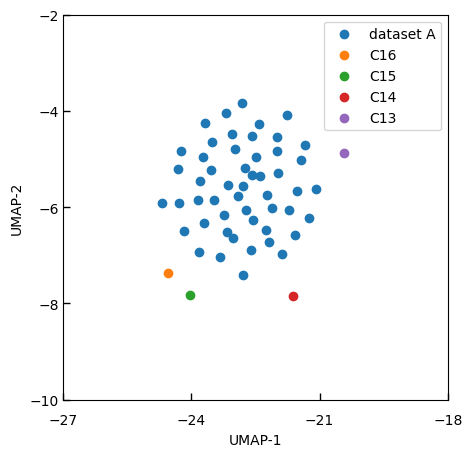

In [14]:
from cuml.manifold.umap import UMAP
import cupy as cp
import matplotlib.pyplot as plt
fig, ax=plt.subplots(figsize=(5, 5))

X_gpu = cp.array(X)
data_for_UMAP = X_gpu


umap = UMAP(n_components=2,  min_dist=0.2, random_state=42, n_neighbors=16, build_algo="nn_descent", build_kwds={"nnd_do_batch": True, "nnd_n_clusters": 4})
emb = umap.fit_transform(data_for_UMAP)
emb_candidate = umap.transform(X_candidate)

ax.scatter(
    cp.asnumpy(emb[:, 0]),
    cp.asnumpy(emb[:, 1]),
    label="dataset A",
    marker ="o",
    c="C0"
    )

names_list = ["C16", "C15", "C14", "C13"]
for i in range(len(names_list)):
    ax.scatter(
    cp.asnumpy(emb_candidate[i, 0]),
    cp.asnumpy(emb_candidate[i, 1]),
    label=names_list[i],
    c=color_list[i],
    )
ax.tick_params(which="major", axis="x",direction="in", left="off",labelleft="on", length=5, width=1, color="black", labelsize=10, labelbottom=10, pad=10)
ax.tick_params(which="major", axis="y",direction="in", left="off",labelleft="on", length=5, width=1, color="black", labelsize=10, labelbottom=10, pad=3)
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")

ax.set_xticks(np.arange(-33, -14, 3))
ax.set_yticks(np.arange(-10, -1.9, 2))
ax.set_xlim(-27, -18)
ax.set_ylim(-10, -2)
ax.set_aspect(1/ax.get_data_ratio())
ax.legend()
import datetime
plt.savefig(f"UMAP_separation_{datetime.date.today()}.pdf")
plt.savefig(f"UMAP_separation_{datetime.date.today()}.svg")
plt.show()
plt.clf()
plt.close()

In [15]:
!uv pip freeze > requirements.txt

Using Python 3.12.13 environment at: /usr
